# Medical Aid Charges Prediction: EDA & Linear Regression
**Author: Sheldon Mellett** 

**Module: PDAN8411w - Programming for Data Analytics**

**Assessment: POE Part 1 (Linear Regression)**

## 📋 Project Outline

1. **Introduction**
2. **Dataset and Data Quality Assessment**
3. **Exploratory Data Analysis (EDA)**
4. **Model Training and Optimising**
5. **Model Evaluation and Interpretation**
6. **Conclusion**
7. **References**

#### 1. Introduction
#### - **1.1. Objective**

The following notebook will attempt to create a regression model that provides a sliding scale of medical aid charges according to client age, sex, BMI, number of children, smoking habits and geographical region. Providing insights into which client lifestyle habits influence medical aid charges may help medical aid companies increase their revenue.

Target variable: 'Charges' is dollars in the dataset, but will be interpreted as South African Rands. This variable would classified as a continuous variable because it is numerical and infinite. This type of variable is often used in prediction models, such as Multiple Linear Regression (Hastie et al., 2017).

#### - **1.2. Dataset overview**

The dataset was obtained by kaggle and contains insurance data from the USA (dollars). 

#### - **1.3. Scope**

Firstly, the plan is to assess the validity of the dataset for use in a regression model. Then, a regressor will be trained and evaluated using tools in the sklearn libary. For a powerful regression model to be built, the dataset needs to follow certain conventions and avoid certain pitfalls. The assumptions of linear regression are:
- **Additivity and Linearity** : is the relationship linear? 
- **Homoscedasticity** : are the errors constant?
- **Error normality** : are the residuals normally distributed?

Common pitfalls include:
- **Non-linear data** : is the data curved instead of straight?
- **Outliers** : are extreme points skewing the model?
- **Multicollinearity** : are the features related?

(Hastie et al., 2017).

#### 2. Dataset and Data Quality Assessment
#### - **2.1. Data Suitability**

The dataset suits linear regression because it has continous variables and because medical aid charges are notoriously linked to lifestyle choices. For instance, discovery tracks clients steps and provides points for steps accumulated. Additionally, the size of the dataset (1338) is well suite to regression.

#### - **2.2. Loading Data & inspection**

In [38]:
# importing the libraries needed for the entire process
import pandas as pd 
import sklearn 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# hiding ugly warning messages
import warnings
warnings.filterwarnings('ignore')

# importing and viewing dataset
df = pd.read_csv('insurance.csv')

# checking the first five records
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [39]:
# checking what data types are present in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


**This** shows that the dataset contains 1338 points and 7 columns. There are **four** numerical variables and **three** categorical columns. 

In [40]:
# descriptive analysis of the numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [41]:
# descriptive analysis of the categorical variables
df.describe(include='object') 

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


**The descriptive analyses** indicate that:  

- **Age** : The minimum client age is 18, which makes sense because it is the start of adulthood. The average age is 30, indicating that most clients are middle aged. This data is normally distributed, making it suited for linear regression. This is assumed because the mean and the median (50% quartile) of this varaible are similar, indicating that the data is symmetrical and normal. 

- **BMI** : The average weight is 30, which indicates that most clients are overweight and potentially living unhealthy lifestyles. This data is also normally distributed. Again, this is because the mean and the median (50% quartile) are similar, indicating that the data is symmetrical and normal. However, there is less variance in this variable (lower std) than in the previous variable (**age**).

- **Children** : The average number of children among clients is 1. The standard deviation of this variable is low (1.205) so the variation of this varaible is low. This means that not many clients have more than 1 or 2 children. The quartiles indicate that 25% of clients have no children, 50% have only 1 child, and 75% have more than 2 children. Overall, clients with many children are rare.

- **Charges** : This is the target variable. The mean and standard deviation are close, indicating that the data has high variance and may be skewed. The median (50% quartile) is lower than the mean, indicating that the data is skewed. The range shows that the max value (R63,770) is way higher than the mean (R13,270), and the 75% quartile (R16,640). This could indicate that there are extreme outliers present in the variable.

- **Sex** : This data is binary and almost equally distributed, with 675 values being male.

- **Smoker** : This data is binary but is not equally distributed, with 1063 values being no. This means that almost 80% of clients are none smokers.

- **Region**: This data is nominal and almost equally distributed, with almost 25% of clients being from the Southeast region.


**Overall**, the variables seem well suited for linear regression because most follow a normal distribution. 

(Caldwell, 2013).

#### - **2.3. Data Quality Assessment and Preprocessing**

- **Missing and Duplicated Values**

In [42]:
# check for missing values 
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [43]:
# check for duplicates
print(f"Duplicates found: {df.duplicated().sum()}")

Duplicates found: 1


In [44]:
# number of duplicates is low so they are getting dropped
df_clean = df.drop_duplicates()
print(f"Duplicates found: {df_clean.duplicated().sum()}")

Duplicates found: 0


- **Encoding Categorical**

In [45]:
# importing encoder
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()

# label encoder for binary variables
arr_sex = lb.fit_transform(df_clean[['sex']])
arr_smoker = lb.fit_transform(df_clean[['smoker']])

df_clean['sex'] = arr_sex
df_clean['smoker'] = arr_smoker

In [46]:
# one hot encoding for region
region_coded = pd.get_dummies(df_clean['region'], drop_first=True, dtype=int)
df_clean = pd.concat([df_clean, region_coded], axis =1)
df_clean.drop(columns = 'region', inplace=True)

In [47]:
# checking that the outcome is correct
df_clean.head()

,age,sex,bmi,children,smoker,charges,northwest,southeast,southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


**The dataset** has no missing or null values and has only one duplicate. This solitary duplicate was dropped as it will likely not affect the final model's performance. The means that the dataset is cleaned and ready for encoding, which involves transforming categorical columns so they can be used in regression. **The binary columns (sex and smoker)** were label encoded because it takes away the need to remove a column; one hot encoding would create two columns for both values. **The region column** was one hot encoded so that the column has no assumed hierachy. This means that if the third region, for instance South West, was labelled as 3, the model would falsely assume that it is greater than the other encoded regions. To avoid this, one hot encoding is used to seperate regions into different columns. 

#### - **2.4. Common Pitfalls**

- **Outliers (checked using IQR)**

In [48]:
# code source: Titanic EDA notebook ARC

# selecting only numerical columns
num_cols = df_clean.select_dtypes(include= ['int64','float64']).columns
print (num_cols)

# looping through each columns checking values outside of Q1 and Q3
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

# creating thresholds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[col]< lower_bound) | (df_clean[col]> upper_bound)]
    print (f'{col}: {len(outliers)} outliers' )

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'northwest',
       'southeast', 'southwest'],
      dtype='object')
age: 0 outliers
sex: 0 outliers
bmi: 9 outliers
children: 0 outliers
smoker: 274 outliers
charges: 139 outliers
northwest: 324 outliers
southeast: 0 outliers
southwest: 325 outliers


- **Multicollinearity**

In [49]:
# code adapted from: 
# https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/
# https://gustavorsantos.medium.com/calculating-variance-inflation-factor-vif-in-python-49e5f48f33bf

# import tools
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# VIF score cannot be done without dropping target and adding a constant
X = add_constant(df_clean.drop('charges', axis=1))

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print(vif_data)

     feature        VIF
0      const  35.504594
1        age   1.016794
2        sex   1.008944
3        bmi   1.106742
4   children   1.004017
5     smoker   1.012100
6  northwest   1.517673
7  southeast   1.651779
8  southwest   1.529044


**Interquartile range** indicates that there are very few outliers for the relevant columns. The outliers in the **smoker and region** variables are irrelevent because these variables have been converted to binary, which means outliers cannot exist. For the **BMI** predictor, the 9 outliers should be kept because these could be clients with high medical aid charges, which could be essential to the prediction model. **Outliers** may skew regression lines but in this case the outliers represent the environment from where the data was collected, and as such should not be adjusted unless it is necessary for accuracy.

**VIF scores** indicate that the variables have very low correlation with one another, meaning that multicollinearity is not to be worried about. There are no redundant variables to take out of the list. **Multicollinearity** is when one or more variables are very closely related, thereby making it difficult to seperate the variable's effect on the target variable (geeksforgeeks, 2025; James et al, 2023).

#### 3. Exploratory Data Analysis (EDA)
#### - **3.1. Univariate Analysis**

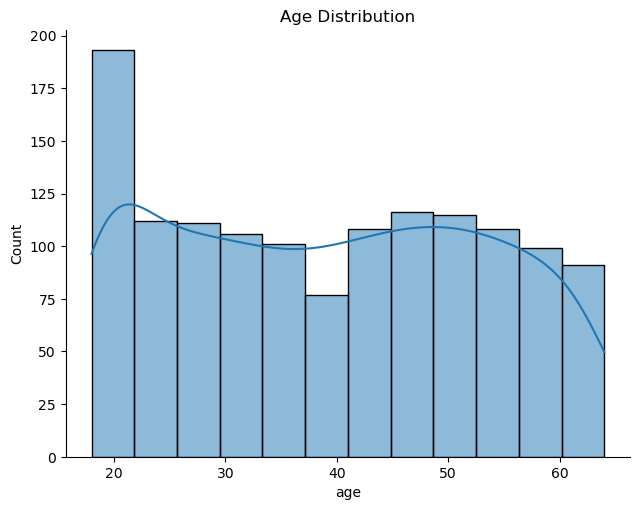

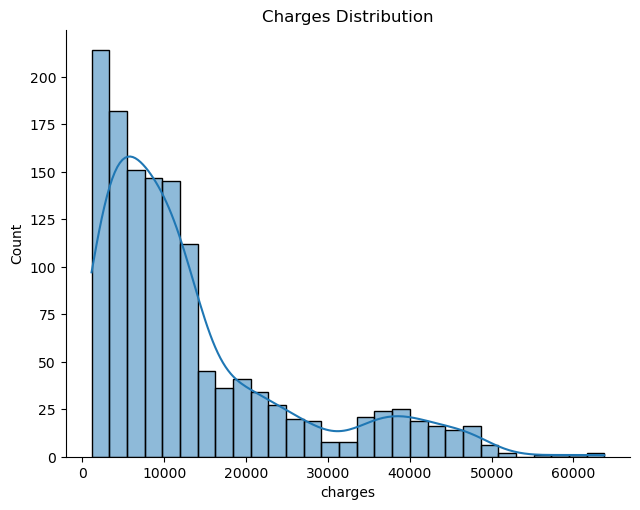

In [50]:
# quick loop for all columns
# created in perplexity.ai 
# link = https://www.perplexity.ai/search/create-loop-from-this-sns-hist-u9mR7xFhQwiqp9nyN2wL2A
for col in ['age', 'charges']:
    sns.displot(data=df_clean, x=col, kde=True, height=5, aspect=1.3)
    plt.title(f'{col.title()} Distribution')
    plt.show()

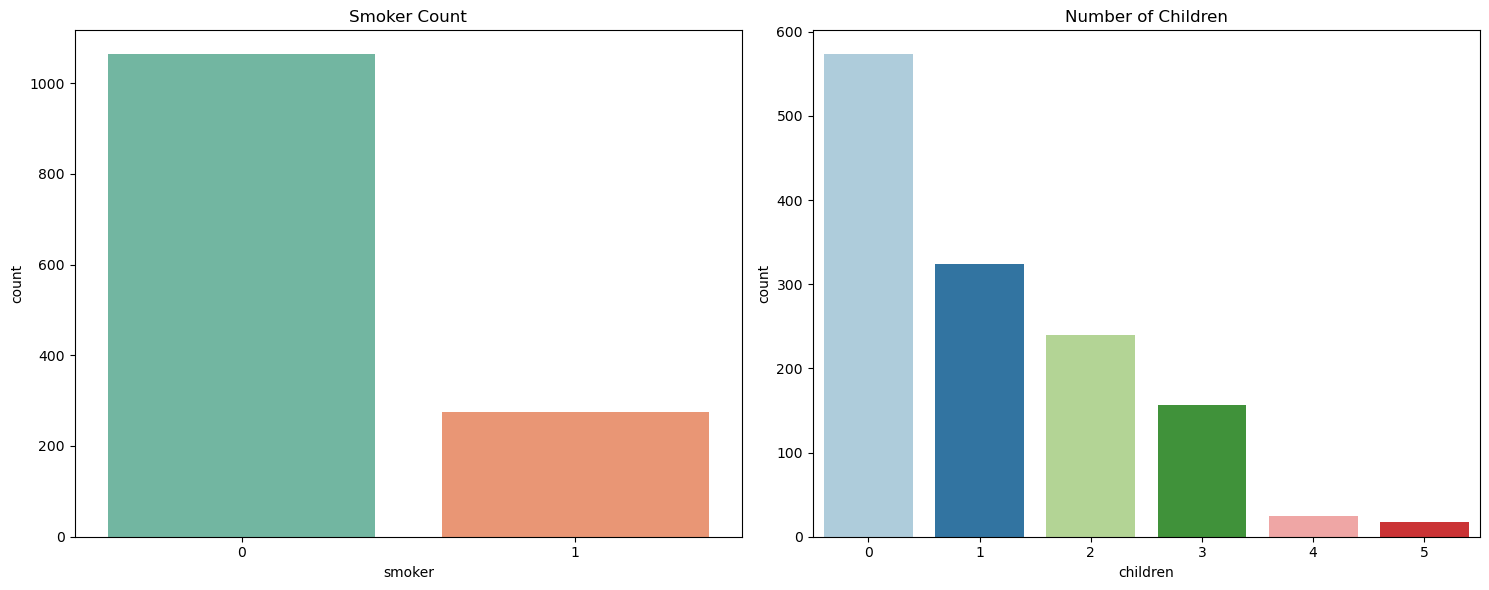

In [51]:
# code from: https://seaborn.pydata.org/generated/seaborn.countplot.html

# figure and axes (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) 

# smoker Count 
sns.countplot(x='smoker', data=df_clean, ax=axes[0], palette='Set2', hue='smoker', legend=False)
axes[0].set_title('Smoker Count')

# children Count
sns.countplot(x='children', data=df_clean, ax=axes[1], palette='Paired', hue='children', legend=False)
axes[1].set_title('Number of Children')

# display
plt.tight_layout()
plt.show() 

**These visualisations** indicate that:
- **Age** : a significant number of younger clients, mainly 20 years old and under. This can be fixed in the data preprocessing stage using standardisation to scale the variables like age and BMI, so all varaibles have the same mean of 0 and standard deviation of 1. 

- **Charges** : the degree of right-skewness is significant, with much of the medical aid charges in the dataset under R15,000. Based on the high number of younger clients shown the age distribution histogram, it can be assumed that most of the young people occupy the left side of the charges distribution. 

- **Smoker** : heavily imbalanced, with non-smokers outnumbering smokers nearly 5 to 1. This imbalance can be fixed using methods like resampling or SMOTE, but in this case because this dataset is being used to build and predict clients' charges for a specific company, changing the dataset would mean that the final analysis and predictions would not be taylored toward their consumer base.

- **Children** : the number of children variable is also imbalanced, with most clients having no children. This supports the previous assumption that as one gets older, gets married, and has children, the insurance rates go higher.


**Overall**, fixing the skewness of the target data can be done using transformations, and fixing the imbalanced variables in the dataset can be done using resampling or SMOTE. However, this dataset represents real world company data, where most people are not smokers and where people with unhealthy lifestyles get charged more for medical aid, so the outliers, imbalancing and skewness may be unique to this specific **client base**. **The following analysis** focuses on visualising perculiar variables such as age, smoker and children in relation to the target variable **charges** as well as checking the correlations between the variables.

#### - **3.2. Bivariate Analysis**
#### - **Plots**

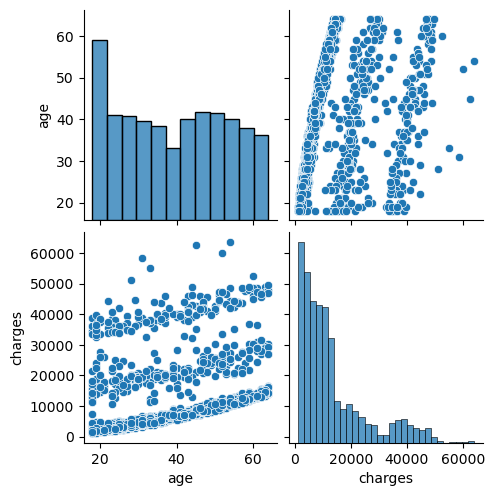

In [52]:
# boolean values make no sense in a pair plot lets not show them
# age and charges plot
sns.pairplot(df_clean, vars=['age','charges'])

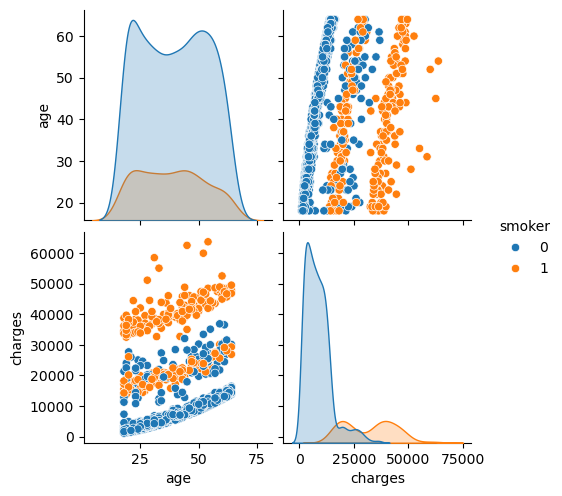

In [53]:
# checking how age and charges relate as well as how being a smoker relates
sns.pairplot(df_clean, vars=['age', 'charges'], hue='smoker')

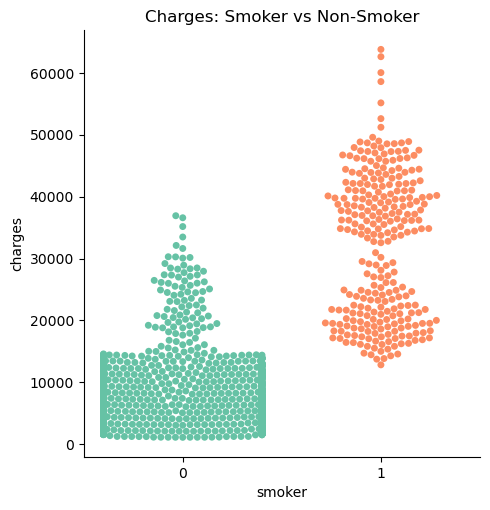

In [54]:
# code from: https://seaborn.pydata.org/tutorial/categorical.html

sns.catplot(data=df_clean, x="smoker", y="charges", kind="swarm", palette='Set2', hue='smoker', legend=False)
plt.title('Charges: Smoker vs Non-Smoker')
plt.show()

#### - **Correlation Heatmap**

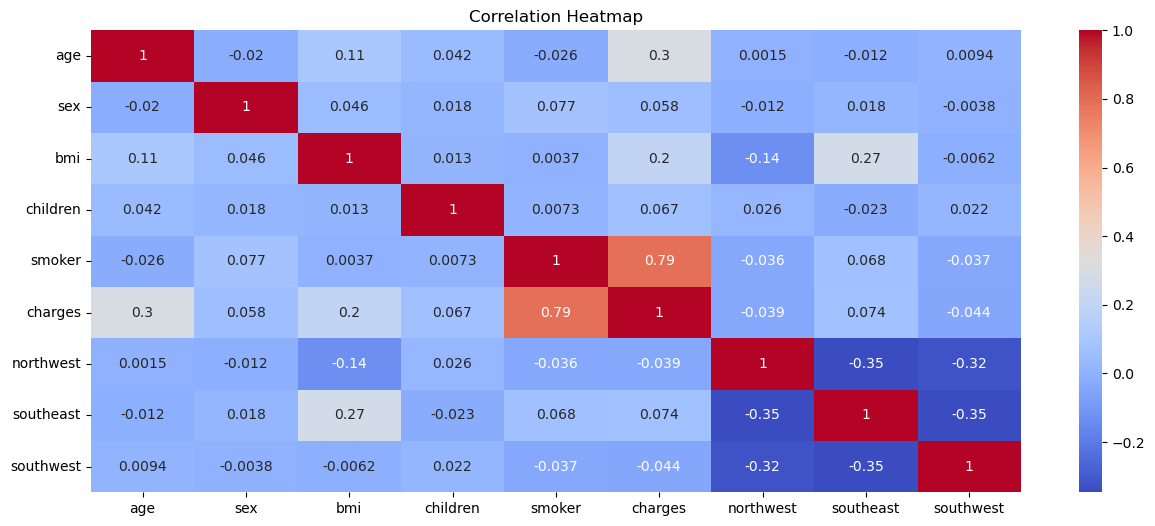

In [55]:
# Visualizing correlations
plt.figure(figsize=(15,6))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**The age and charges plot** indicates that the two variables are scattered evenly. **The age, smoker and medical aid charges plot** indicates that the points above R30 000,00 are almost all smokers. The smoker group on the bottom right hand graph appears to be bimodal, meaning there are two modes. The smoker variable follows a similar upward trend to the predictor age.

**The smoker and medical aid charges plot** indicates that smoking is correlated with medial aid charges, so being a smoker would increase a clients' medical aid charges, as shown in the graph. This represents the real world, where there are a low percentage of smokers and the people with high **charges** are the ones with chronic illnesses (usually smokers).**The smoker group** on the right appears to have two groups (as noted before), one new or healthy smokers and one being smokers with complications. 

**The correlation heatmap** shows that being a smoker has the highest correlation with increased medical age charges (0.79). This analysis shows that the predictor **age** has the second strongest correlation (0.3), while BMI (0.2) and children (0.06) follow behind. This indicates that generally an increase in age or bmi will also lead to an increase in medical aid charges.

**Overall**, this analysis verified the linearity of the variables under investigation, making them suited for regression. **The heatmap** provides proof that the plots are true.

#### - **3.3. Feature Selection**

In [56]:
# dropping useless columns
df_new = df_clean.copy()
df_new.drop(columns = ['northwest', 'southwest'], inplace= True)

In [57]:
# checking the variables dropped
df_new.head()

,age,sex,bmi,children,smoker,charges,southeast
0,19,0,27.900,0,1,16884.92400,0
1,18,1,33.770,1,0,1725.55230,1
2,28,1,33.000,3,0,4449.46200,1
3,33,1,22.705,0,0,21984.47061,0
4,32,1,28.880,0,0,3866.85520,0


**Based on the EDA**, some features considered should not be included in the model. With no multicollinearity to worry about, the plots and correlation heatmap justify the inclusion of certain variables (smoker, age, bmi, children, sex, southeast) and the exclusion of other variables (northwest, southwest). The excluded variables have very low correlation, meaning they lack prediction power.

**IN**
- **smoker (0.787234)**
- **age (0.298308)**
- **bmi (0.198401)**
- **southeast (0.073578)**
- **children (0.067389)**
- **sex (0.058044)**

**OUT**
- **northwest (-0.038695)**
- **southwest (-0.043637)**

#### 4. Model Training and Optimising
#### - **4.1. Split Data**

In [58]:
# splitting data into X and y
X = df_new [['smoker', 'age', 'bmi', 'southeast', 'children','sex']] 
y = df_new ['charges']

# checking the split worked
print (y.head()) 
print (X.head())

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64
   smoker  age     bmi  southeast  children  sex
0       1   19  27.900          0         0    0
1       0   18  33.770          1         1    1
2       0   28  33.000          1         3    1
3       0   33  22.705          0         0    1
4       0   32  28.880          0         0    1


In [59]:
# importing tool for splitting
from sklearn.model_selection import train_test_split

# defining training and test groups
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.2, random_state = 42)

**Here** the dataset is split into training and test sets using the X and y made earlier in the code. The test size is set at 20%, so 20% of the data will be the test set and 80% will be the training set. **Splitting** the data should be done before scaling to avoid data leakage. If the whole dataset is scaled, then the data intended to be the test dataset is used to scale and transform the data meant to be the training set. **Thus, to avoid data leakage and overfitting**, the dataset is split into training and test sets first before scaling (scikit-learn).

#### - **4.2. Feature Scaling**

In [60]:
# importing neccessary tools
from sklearn.preprocessing import StandardScaler

# define the tool
stand_scaler = StandardScaler()

# only numeric columns
num_cols = ['age', 'bmi', 'children']

X_train[num_cols] = stand_scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = stand_scaler.transform(X_test[num_cols])

**Scaling** involves changing the distribution of variables to make them all equal. This transforms the data, converting all predictor variables to the same scale by setting them all to a mean of 0 and standard deviation of 1. **Standardisation** is used in this case because the dataset contains some normally distributed data, such as age. Scaling must only be done on the numerical features or predictor variables to avoid having to try make sense of messy decimal binary columns. **Additionally**, the target variable is avoided because converting charges back into currency after scaling and predicting is unessessary work (geeksforgeeks, 2021).

#### - **4.3. Training Models**

In [61]:
# code source: https://mljourney.com/step-by-step-linear-regression-in-jupyter-notebook/
# importing linear regression model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

# fitting the model 
regressor.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Training** a model involves fitting a linear regressor to the training dataset, thereby training the model to predict the data in the test set. After training, the model is used to make predictions based on the predictor test set (X test set). To evaluate the predictive power of the model, the model's predictions of the predictor test set are compared to the real answers (y test set) using the **.score** function.

#### - **4.4. Model Coefficients**

In [62]:
# printing the model coefficients
print(f"Model intercept: {regressor.intercept_:.2f}")
print("\nModel coefficients:")
for feature, coef in zip(X.columns, regressor.coef_):
    print(f"  {feature}: {coef:.2f}")

Model intercept: 8581.22

Model coefficients:
  smoker: 23094.32
  age: 3474.85
  bmi: 1906.17
  southeast: -471.25
  children: 637.72
  sex: -92.68


**The above coefficients** indicate that the biggest influences on insurance charges, as seen in the correlation heatmap earlier, are smoking and children. **These coefficients** can be interpretted as the expected change in the dependent or target variable given a one unit increase in the predictor while holding all other predictors constant. **For instance**, a one unit increase in age would result in an increase of R3474,85 in medical aid charges, while being a smoker would increase the charges exponentially (smartstat).

#### 5. Model Evaluation and Interpretation
#### - **5.1. Predictions**

In [63]:
# making predictions
predictions = regressor.predict(X_test)

#### - **5.2. Performance Analysis**

In [64]:
# code source: https://stackoverflow.com/questions/27928275/find-p-value-significance-in-scikit-learn-linearregression
# checking significance (P-value) of features
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)  
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     477.4
Date:                Thu, 23 Apr 2026   Prob (F-statistic):          2.19e-297
Time:                        13:17:14   Log-Likelihood:                -10832.
No. Observations:                1069   AIC:                         2.168e+04
Df Residuals:                    1062   BIC:                         2.171e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8581.2236    301.496     28.462      0.0

In [65]:
# code source: linear regession notebook ARC
from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_error,r2_score

print("MAE:", mean_absolute_error(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))
print("R²:", r2_score(y_test, predictions))
print("RMSE:", root_mean_squared_error(y_test,predictions))

MAE: 4190.3995505092225
MSE: 35759004.38582984
R²: 0.8053995955320861
RMSE: 5979.883308713461


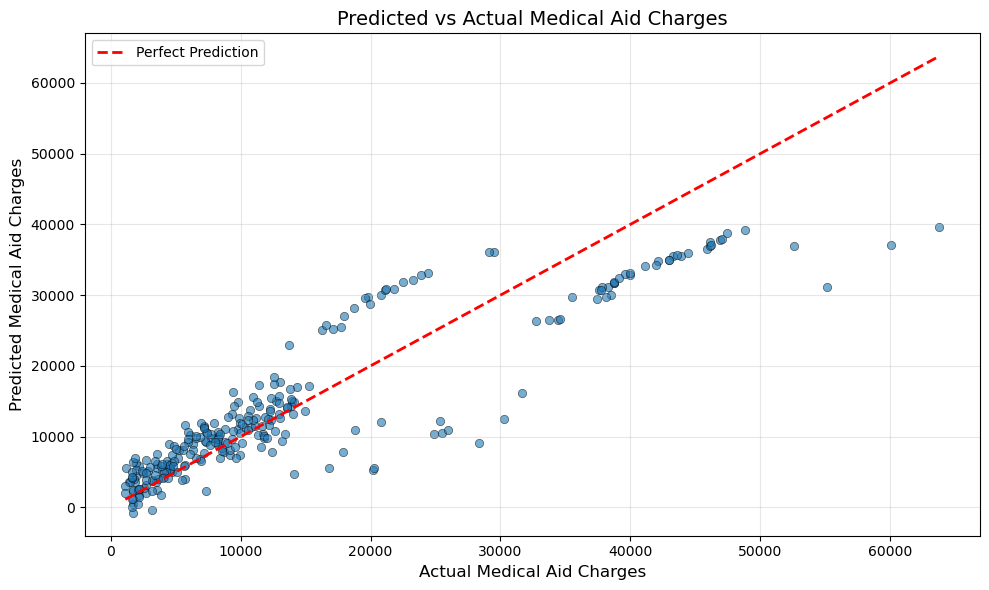

In [66]:
# code source: https://mljourney.com/step-by-step-linear-regression-in-jupyter-notebook/
# Predicted vs Actual plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Medical Aid Charges', fontsize=12)
plt.ylabel('Predicted Medical Aid Charges', fontsize=12)
plt.title('Predicted vs Actual Medical Aid Charges', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**The P-values** verify the ealier assumptions that smoker (0.0), age (0.0), bmi (0.0), and children (0.001) are the most influencial variables in predicting medical aid charges. However, the variable south east (0.284) and sex (0.85) identified as statistically insignificant in predicting charges. Overall, a higher p-value indicates that the affect of the predictor on the target is likely due to chance, whereas a lwoer p-value indicates that the affect is less likely due to chance (Caldwell, 2013).

**The evaluation metrics** is the previous code block focus on the errors made by the model during prediction. **The MAE** indicates that, on average, the model's predictions are off by about R4190,39. **The MSE** is very large because the prediction errors, in this case insurance charges, are being squarred. This heavily increases the value of the errors. **The RMSE** is better interpretted because it involves individual errors. **In this case**, the model is making large individual errors, likely on who clients have really high insurance charges. **This** can be due to the mass amount of outliers present as well as the skewed target variable data (mljourney, 2025).

**The visualisation** supports the assumptions made before building the model. The target variable is right-skewed, so majority of training data came from the more populated side of the data, in this case clients paying under R15 000,00. Combined with the skewed smoker count and the fact that majority of the clients are young individuals, one can gather why the model is underpredicting higher-cost individuals. The error in prediction gets higher as the medical aid charges increase. There is some coning present in the plot, with predictions getting less accurate as you move toward the left of the graph (heteroscedasticity) (Hastie et al., 2017).

**Overall**, the r-squared score is quite high so transforming skewed data and removing outliers might only increase the models accuracy by a very small percentage. 

#### - **5.3. Residual Analysis**

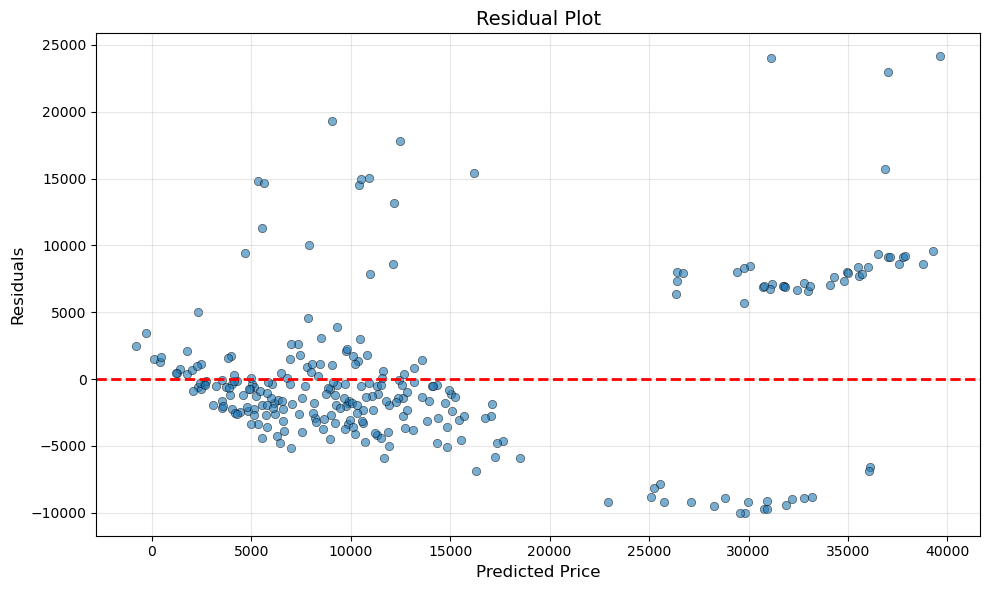

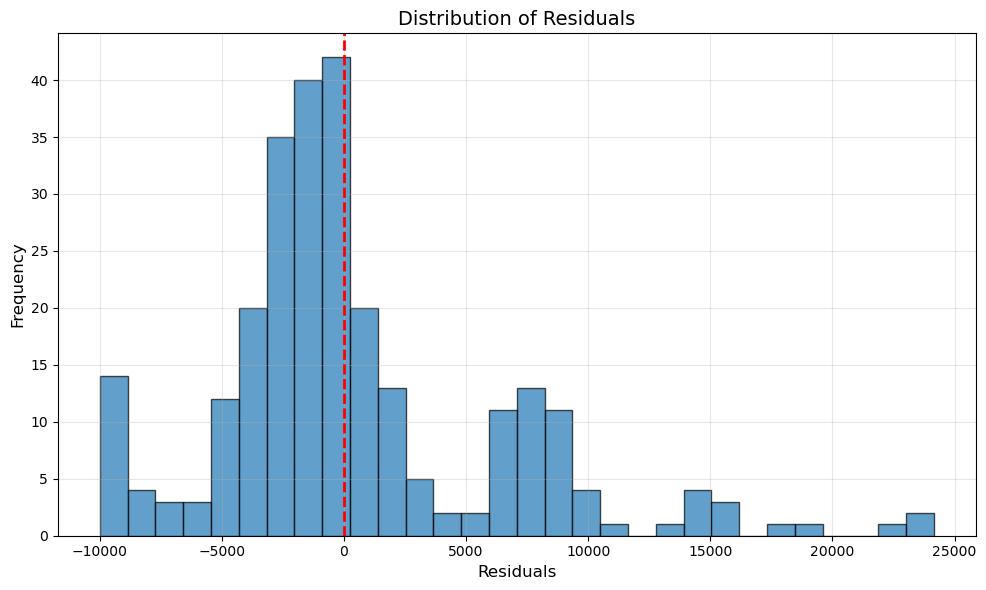

In [67]:
# code source: https://mljourney.com/step-by-step-linear-regression-in-jupyter-notebook/
# Residual plot
residuals = y_test - predictions
 
plt.figure(figsize=(10, 6))
plt.scatter(predictions, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Price', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residual Plot', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
# Residual distribution
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Residuals', fontsize=14)
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**The residuals plot** confirms the previous assumptions that the model confidently predicts clients with low medical aid charges, and that the model becomes less accurate as the medical aid charges increase. **The distribution visualisation** shows that the residuals centre around zero, meaning that for most clients this model's predictions will have little error. **However**, the distribution of the residuals to the right hand side insist that the model underpredicts clients medical aid charges, which is a big problem for a medical aid company because this might lose the business money (insuranceopedia, 2024).

#### - **5.4. Interpretation and Evaluation**

In [68]:
# training and test scores (R²)
train_score = regressor.score(X_train, y_train)
test_score = regressor.score(X_test, y_test)

print("Training R²:", train_score)
print("Test R²:", test_score)

Training R²: 0.7295216768141505
Test R²: 0.8053995955320861


In [69]:
# code source: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores = cross_val_score(regressor, X_train, y_train, cv=5)

print(f"All CV Scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

All CV Scores: [0.69456103 0.764591   0.72002913 0.70616656 0.74342566]
Mean R²: 0.7258
Standard Deviation: 0.0253


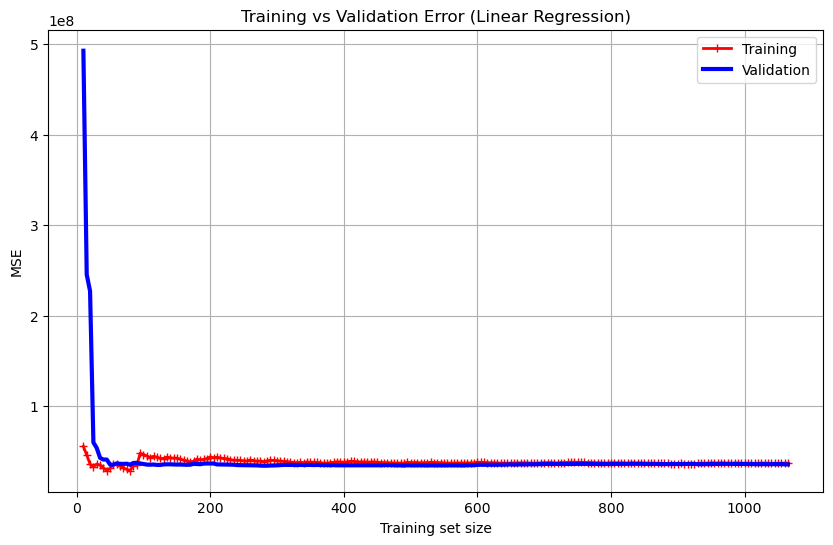

In [70]:
# code source: linear regression notebook ARC
train_errors, val_errors = [], []
training_sizes = range(10, len(X_train), 5)

for m in training_sizes:
    model = LinearRegression().fit(X_train[:m], y_train[:m])
    y_train_predict = model.predict(X_train[:m])
    y_val_predict = model.predict(X_test)
    train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
    val_errors.append(mean_squared_error(y_test, y_val_predict))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(training_sizes, train_errors, "r-+", linewidth=2, label="Training")
plt.plot(training_sizes, val_errors, "b-", linewidth=3, label="Validation")
plt.xlabel("Training set size")
plt.ylabel("MSE")
plt.title("Training vs Validation Error (Linear Regression)")
plt.legend()
plt.grid()
plt.show()

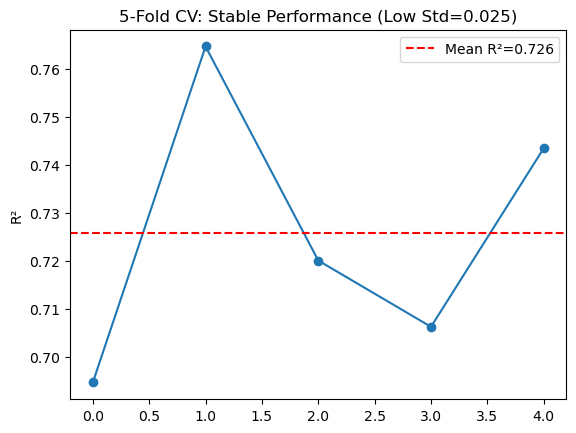

In [71]:
# code source: https://codepointtech.com/mastering-ml-how-to-plot-learning-curves-with-scikit-learn/
# plotting learning curve
cv_scores = [0.6946, 0.7646, 0.7200, 0.7062, 0.7434]  # Your results
plt.plot(cv_scores, 'o-')
plt.axhline(y=np.mean(cv_scores), color='r', ls='--', label=f'Mean R²=0.726')
plt.title('5-Fold CV: Stable Performance (Low Std=0.025)')
plt.ylabel('R²')
plt.legend()
plt.show()

**The results** confirm assumptions made about the variables in the beginning of the notebook during the EDA process. **Smoking** is the largest coefficient, and is therefore the primary driver of high medical aid costs. As mentioned earlier, this could be because smokers have a higher tendency to fall ill. **Age and bmi** are the second largest driver because as people get older and unhealthier, the chances of becoming ill rise along with medical aid charges. 

**The training and test scores** show that the model is underpredicting on the training set (0.72) as compared to the test set (0.8). This could be due to more outliers in the training dataset compared to the test dataset. Fixing this may involve removing the outliers found in the charges and region variables earlier in the notebook. **Another cause** of the low training score may be chance.

**The cross validation scores** indicate that the model's estimated average performance is around 0.72, which is lower than the single test set score and on par with the single training set score. **This** justifies the fact that the model got lucky on the single test set, because the performance, or r-squared, was above average. **The model** peaks at 1 fold, gets worse at 2 and 3 folds, but improves and settles down at 4 folds. **The standard deviation** is very low indicating stability acoss different folds, but the fluctuating CV scores mean that the distribution of outliers may be imbalanced (some training sets had more outliers than others).

**The training error and validation error plot** shows that the model easily remembers data but has more error when it encounters extreme data. **It also shows** that the validation error of the model, known as the models performance on unseen data, starts with high errors but it improves very fast. The training and validation plotted lines are very close together, with the MSE staying high and not improving as much as it should. This could mean that the model is underfitting and bias towards lower paying clients (dataquest, 2018). 

#### 6. Conclusion
#### - **6.1.Recommendations**

**Overall**, the model is quite accurate on lower paying clients, but this could be further enhanced by doing the following:
- **Feature engineering** : dropping the statistically insignificant variables and creating interaction terms could help increase the accuracy of the model. For instance, creating an obese variable (bmi>30 and smoker=1). 

- **Removing or capping outliers** : the model is influenced by outliers, thus removing them will unskew the MSE and might increase accuracy.

- **Selecting a more flexible model** : while the accuracy of this linear regression model is very good, this could be increased by using a model that can capture non-linear data better. For instance, using polynomial regression to fit a curve line instead on straight one (geeksforgeeks, 2025).

- **Target variable transformation** : the target variable (charges) is right-skewed so transforming it into a normal distribution using a tool like Log transformation could improve the models accuracy (geeksforgeeks, 2025).

- **Resampling** : there is class imbalancing for features like smoker and children. Resampling to make the groups more even may improve accuracy.

#### - **6.2.Synopsis of Research and Findings**

**Overall**, the interpretation and evaluation has shown that the model built is accurate on clients who are paying below R15 000,00 in medical aid charges. This could be due to the fact that almost 50% (quartile 2) of the sample has insurance charges under R10 000,00 (as seen using df.describe). **In terms of demographics**, smoking is the greatest predictor of medical aid charges (0.78), followed by age (0.3), bmi (0.2) and children (0.06). **Almost** R23 000,00 is added onto **medical aid charges** for being a **smoker**, likely due to the higher chance of falling ill. **Age** adds R3,472,98 while **bmi** adds roughly R2000,00. **From a regional context**, the southeast is the most frequent region and also has the lowest coefficient. **All regions** have negative coefficients, implying that residents are likely saving money. Finally, as compared to other models built in kaggle listed below, the accuracy of this model is similar. These models have an R-squared that ranges between 0.6 and 0.8 which is similar to this model at 0.75.


**Models**

https://www.kaggle.com/code/mariapushkareva/medical-insurance-cost-with-linear-regression

https://www.kaggle.com/code/sudhirnl7/linear-regression-tutorial

https://www.kaggle.com/code/hely333/eda-regression/notebook


#### 7. References

Hastie, T., Tibshirani, R. and Friedman, R., 2017. The Elements of Statistical Learning: Data Mining, Inference, and Prediction. 2nd edition. New York: Springer.  

Caldwell, S., 2013. Statistics Unplugged. 4th edition. Belmont, CA: Cengage Learning. 

Detecting multicollinearity with vif in python. 2025. https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/

James, G., Witten, D., Hastie, T., Tibshirani, R. and Taylor, J., 2023. An Introduction to Statistical Learning: With Applications in Python. Cham: Springer International Publishing. 

https://scikit-learn.org/stable/common_pitfalls.html

Normalization vs Standardization. 2021. https://www.geeksforgeeks.org/machine-learning/normalization-vs-standardization/

Simple Linear Regression. https://www.smartstat.info/en/materi/statistika/regresi/simple-linear-regression.html

Step-by-Step Linear Regression in Jupyter Notebook. 2025. https://mljourney.com/step-by-step-linear-regression-in-jupyter-notebook/

Underwriting Risk. 2024. https://www.insuranceopedia.com/definition/4699/underwriting-risk

Tutorial: Learning Curves for Machine Learning in Python. 2018. https://www.dataquest.io/blog/learning-curves-machine-learning/

Log Transformation. 2025. https://www.geeksforgeeks.org/data-science/log-transformation/

Implementation of Polynomial Regression. 2025. https://www.geeksforgeeks.org/machine-learning/python-implementation-of-polynomial-regression/